In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

project_path = '/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls'

# Check if the path exists
if os.path.exists(project_path):
    print(f"Contents of '{project_path}':")
    for item in os.listdir(project_path):
        print(item)
else:
    print(f"The specified path '{project_path}' does not exist. Please check the path and try again.")

Contents of '/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls':
test
train


In [3]:
import os

train_path = os.path.join(project_path, 'train')
test_path = os.path.join(project_path, 'test')

print(f"\nContents of the 'train' directory ({train_path}):")
if os.path.exists(train_path):
    for item in os.listdir(train_path):
        print(item)
else:
    print(f"The 'train' directory '{train_path}' does not exist.")

print(f"\nContents of the 'test' directory ({test_path}):")
if os.path.exists(test_path):
    for item in os.listdir(test_path):
        print(item)
else:
    print(f"The 'test' directory '{test_path}' does not exist.")


Contents of the 'train' directory (/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls/train):
baseball
football
tennis_ball
golf_ball
basketball
american_football

Contents of the 'test' directory (/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls/test):
football
basketball
american_football
baseball
golf_ball
tennis_ball


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Contents of '/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls':

test
train

Train Path: /content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls/train
Test Path : /content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls/test

Loading Training Data...

Loading class: american_football
Loading class: baseball
Loading class: basketball
Loading class: football
Loading class: golf_ball
Loading class: tennis_ball

Loading Testing Data...

Loading class: american_football
Loading class: baseball
Loading class: basketball
Loading class: football
Loading class: golf_ball
Loading class: tennis_ball

Training Shape: (1407, 256, 256, 3)
Testing Shape : (289, 256, 256, 3)

Class Mapping:

0 -> american_football
1 -> baseball
2 -> basketball
3 -> football
4 -> golf_bal

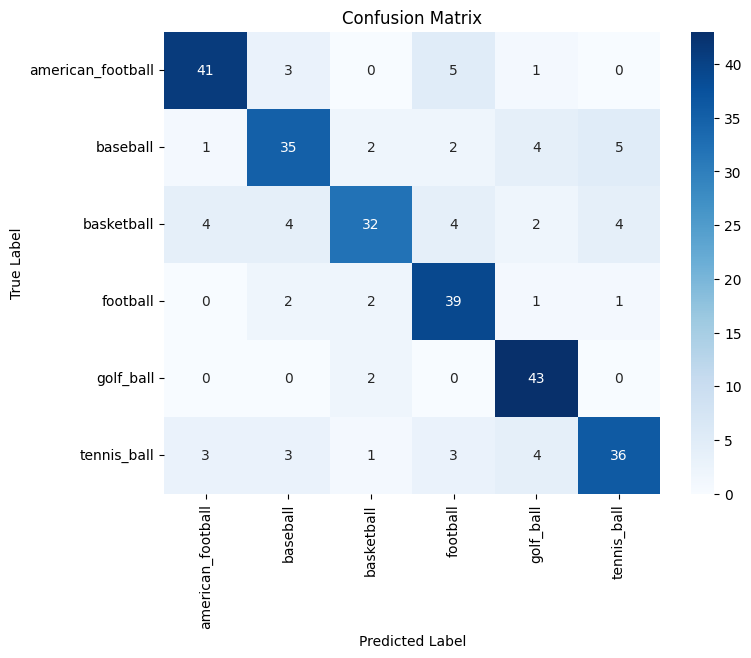


Displaying Predictions...

Predicted: american_football
Actual   : american_football


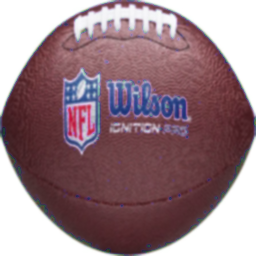

------------------------------------------------
Predicted: american_football
Actual   : american_football


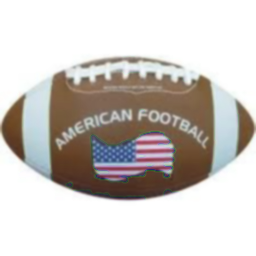

------------------------------------------------
Predicted: baseball
Actual   : american_football


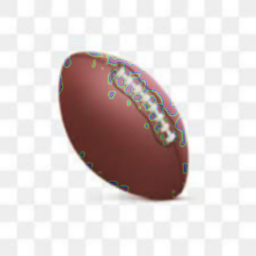

------------------------------------------------
Predicted: american_football
Actual   : american_football


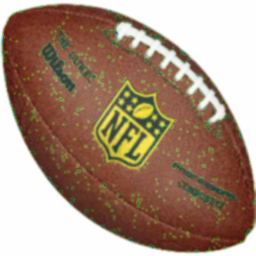

------------------------------------------------
Predicted: american_football
Actual   : american_football


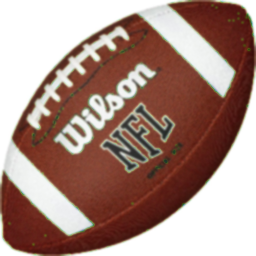

------------------------------------------------
Predicted: american_football
Actual   : american_football


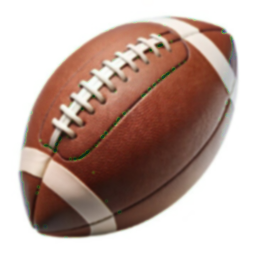

------------------------------------------------
Predicted: american_football
Actual   : american_football


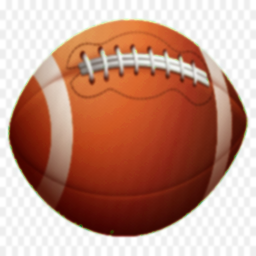

------------------------------------------------
Predicted: american_football
Actual   : american_football


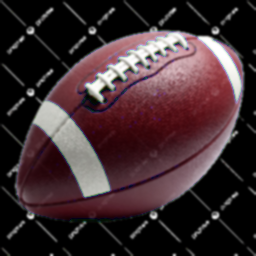

------------------------------------------------
Predicted: american_football
Actual   : american_football


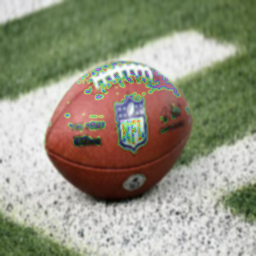

------------------------------------------------
Predicted: football
Actual   : american_football


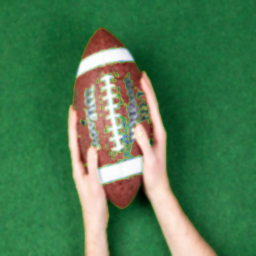

------------------------------------------------


In [5]:
# ============================================
# IMPROVED CLASSICAL IMAGE CLASSIFICATION
# OpenCV + HOG + SVM (RBF)
# ============================================


# =========================
# IMPORT LIBRARIES
# =========================

import cv2
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from google.colab.patches import cv2_imshow

from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import StandardScaler


# =========================
# MOUNT GOOGLE DRIVE
# =========================

drive.mount('/content/drive')


# =========================
# PROJECT PATH
# =========================

project_path = '/content/drive/MyDrive/Image project /dataset-balls-20260507T135657Z-3-001/dataset-balls'

# Check project contents
if os.path.exists(project_path):

    print(f"\nContents of '{project_path}':\n")

    for item in os.listdir(project_path):
        print(item)

else:
    print(f"The specified path '{project_path}' does not exist.")


# =========================
# DATASET PATHS
# =========================

train_path = os.path.join(project_path, 'train')
test_path  = os.path.join(project_path, 'test')

print("\nTrain Path:", train_path)
print("Test Path :", test_path)


# =========================
# PARAMETERS
# =========================

IMG_SIZE = 256


# =========================
# ARRAYS
# =========================

x_train = []
y_train = []

x_test = []
y_test = []

class_names = []


# =========================
# LOAD TRAINING DATA
# =========================

print("\nLoading Training Data...\n")

i = 0

for foldername in sorted(os.listdir(train_path)):

    folder_path = os.path.join(train_path, foldername)

    if not os.path.isdir(folder_path):
        continue

    class_names.append(foldername)

    print("Loading class:", foldername)

    for filename in os.listdir(folder_path):

        img_path = os.path.join(folder_path, filename)

        img = cv2.imread(img_path)

        if img is None:
            continue

        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Convert to HSV
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # Blur
        hsv = cv2.GaussianBlur(hsv, (5,5), 0)

        x_train.append(hsv)
        y_train.append(i)

    i += 1


# =========================
# LOAD TESTING DATA
# =========================

print("\nLoading Testing Data...\n")

j = 0

for foldername in sorted(os.listdir(test_path)):

    folder_path = os.path.join(test_path, foldername)

    if not os.path.isdir(folder_path):
        continue

    print("Loading class:", foldername)

    for filename in os.listdir(folder_path):

        img_path = os.path.join(folder_path, filename)

        img = cv2.imread(img_path)

        if img is None:
            continue

        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Convert to HSV
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # Blur
        hsv = cv2.GaussianBlur(hsv, (5,5), 0)

        x_test.append(hsv)
        y_test.append(j)

    j += 1


# =========================
# CONVERT TO NUMPY ARRAYS
# =========================

x_train = np.array(x_train)
y_train = np.array(y_train)

x_test = np.array(x_test)
y_test = np.array(y_test)


# =========================
# DATASET INFO
# =========================

print("\nTraining Shape:", x_train.shape)
print("Testing Shape :", x_test.shape)


# =========================
# CLASS MAPPING
# =========================

print("\nClass Mapping:\n")

for idx, name in enumerate(class_names):
    print(idx, "->", name)


# =========================
# FEATURE EXTRACTION
# HOG + COLOR HISTOGRAM
# =========================

print("\nExtracting Features...\n")

x_train_features = []
x_test_features = []


# =========================
# TRAIN FEATURES
# =========================

for img in x_train:

    # HSV -> BGR -> GRAY
    bgr = cv2.cvtColor(img, cv2.COLOR_HSV2BGR)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    # HOG FEATURES
    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        visualize=False
    )

    # COLOR HISTOGRAMS
    hist_h = cv2.calcHist([img], [0], None, [32], [0,256])
    hist_s = cv2.calcHist([img], [1], None, [32], [0,256])
    hist_v = cv2.calcHist([img], [2], None, [32], [0,256])

    color_features = np.concatenate([
        hist_h.flatten(),
        hist_s.flatten(),
        hist_v.flatten()
    ])

    # Normalize histogram
    color_features = color_features / np.sum(color_features)

    # Combine Features
    combined_features = np.concatenate([
        hog_features,
        color_features
    ])

    x_train_features.append(combined_features)


# =========================
# TEST FEATURES
# =========================

for img in x_test:

    bgr = cv2.cvtColor(img, cv2.COLOR_HSV2BGR)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    # HOG FEATURES
    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        visualize=False
    )

    # COLOR HISTOGRAMS
    hist_h = cv2.calcHist([img], [0], None, [32], [0,256])
    hist_s = cv2.calcHist([img], [1], None, [32], [0,256])
    hist_v = cv2.calcHist([img], [2], None, [32], [0,256])

    color_features = np.concatenate([
        hist_h.flatten(),
        hist_s.flatten(),
        hist_v.flatten()
    ])

    # Normalize histogram
    color_features = color_features / np.sum(color_features)

    # Combine Features
    combined_features = np.concatenate([
        hog_features,
        color_features
    ])

    x_test_features.append(combined_features)


# =========================
# CONVERT FEATURES TO NUMPY
# =========================

x_train_features = np.array(x_train_features)
x_test_features = np.array(x_test_features)

print("\nTrain Features Shape:", x_train_features.shape)
print("Test Features Shape :", x_test_features.shape)


# =========================
# OUTPUT FEATURE VECTOR
# =========================

print("\n==============================")
print("OUTPUT FEATURE VECTOR")
print("==============================")

print("\nFeature Vector Shape:")
print(x_train_features[0].shape)

print("\nFirst 20 Values of Feature Vector:")
print(x_train_features[0][:20])

print("\nTotal Number of Features:")
print(len(x_train_features[0]))


# =========================
# NORMALIZE FEATURES
# =========================

print("\nNormalizing Features...\n")

scaler = StandardScaler()

x_train_features = scaler.fit_transform(x_train_features)
x_test_features = scaler.transform(x_test_features)


# =========================
# TRAIN SVM MODEL
# =========================

print("\nTraining Improved SVM Model...\n")

# START TIMER
start_time = time.time()

model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

model.fit(x_train_features, y_train)

# END TIMER
end_time = time.time()

training_time = end_time - start_time

print("Training Complete.")


# =========================
# TOTAL TRAINING RUNTIME
# =========================

print("\n==============================")
print("TOTAL TRAINING RUNTIME")
print("==============================")

print(f"\nTraining Time: {training_time:.2f} seconds")


# =========================
# TEST MODEL
# =========================

print("\nTesting Model...\n")

y_pred = model.predict(x_test_features)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy =", accuracy * 100, "%")


# =========================
# CLASSIFICATION REPORT
# =========================

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


# =========================
# CONFUSION MATRIX
# =========================

print("\n==============================")
print("CONFUSION MATRIX")
print("==============================")

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()


# =========================
# DISPLAY PREDICTIONS
# =========================

print("\nDisplaying Predictions...\n")

num_images = min(10, len(x_test))

for i in range(num_images):

    prediction = model.predict([x_test_features[i]])[0]

    predicted_label = class_names[prediction]
    actual_label = class_names[y_test[i]]

    print("Predicted:", predicted_label)
    print("Actual   :", actual_label)

    # Convert image back for display
    display_img = cv2.cvtColor(x_test[i], cv2.COLOR_HSV2BGR)

    cv2_imshow(display_img)

    print("------------------------------------------------")